<a href="https://colab.research.google.com/github/bhoomikatalluri-stack/Dissertation/blob/main/Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4 – Results and Analysis
## Predicting Loan Default Risk Using Transaction and Repayment Behaviour Data
### LD7083 – Computing and Digital Technologies Project Dissertation
---
**Models:** Logistic Regression | Random Forest | Gradient Boosting  
**Dataset:** Loan Default Prediction Dataset (Kaggle) – 255,347 records × 18 variables  
**Metrics:** Accuracy · Precision · Recall · F1-Score · ROC-AUC

---
## 4.1 Introduction

This chapter presents the empirical results of applying three supervised machine learning models — **Logistic Regression (LR)**, **Random Forest (RF)**, and **Gradient Boosting (GB)** — to predict loan default risk using the Loan Default Prediction dataset. The chapter proceeds as follows: Section 4.2 presents dataset overview and preparation; Section 4.3 reports Exploratory Data Analysis; Section 4.4 details individual model results; Section 4.5 compares all models; Section 4.6 covers cross-validation; Section 4.7 highlights key findings.

All 14 figures referenced in the dissertation (Figures 4.1–4.14) are produced using the actual dataset. To address class imbalance (11.6% default minority class), `class_weight='balanced'` is applied and **threshold optimisation** via the Precision-Recall curve is used to identify the probability cut-off maximising F1-score.

---
## Step 0 – Import Libraries

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, precision_recall_curve
)

plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans',
                     'axes.spines.top': False, 'axes.spines.right': False})
sns.set_theme(style='whitegrid')
C = {'lr': '#2196F3', 'rf': '#4CAF50', 'gb': '#FF9800',
     'pos': '#F44336', 'neg': '#2196F3'}

print('All libraries imported successfully.')

All libraries imported successfully.


---
## 4.2 Dataset Overview and Preparation Results

The dataset contains 255,347 anonymised borrower records and 18 variables covering demographic, loan, and behavioural financial characteristics. The target variable `Default` is binary (1 = defaulted, 0 = non-default). There are **no missing values**. The preprocessing pipeline: (1) drop LoanID, (2) binary-encode Yes/No fields, (3) one-hot encode multi-class categoricals, (4) StandardScaler normalise numericals, (5) stratified 80/20 train-test split.

In [2]:
df = pd.read_csv('/content/Loan_default.csv')
print(f'Shape          : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Missing values : {df.isnull().sum().sum()}')
print(f'Columns        : {df.columns.tolist()}')
df.head()

Shape          : 255,347 rows x 18 columns
Missing values : 0
Columns        : ['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [3]:
df.describe().round(2)

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.00,255347.00,255347.00,255347.00,255347.00,255347.00,255347.00,255347.00,255347.00,255347.00
mean,43.50,82499.30,127578.87,574.26,59.54,2.50,13.49,36.03,0.50,0.12
std,14.99,38963.01,70840.71,158.90,34.64,1.12,6.64,16.97,0.23,0.32
min,18.00,15000.00,5000.00,300.00,0.00,1.00,2.00,12.00,0.10,0.00
25%,31.00,48825.50,66156.00,437.00,30.00,2.00,7.77,24.00,0.30,0.00
50%,43.00,82466.00,127556.00,574.00,60.00,2.00,13.46,36.00,0.50,0.00
75%,56.00,116219.00,188985.00,712.00,90.00,3.00,19.25,48.00,0.70,0.00
max,69.00,149999.00,249999.00,849.00,119.00,4.00,25.00,60.00,0.90,1.00


In [4]:
# ── Preprocessing ────────────────────────────────────────────────────────────
df_model = df.drop(columns=['LoanID'])
for col in ['HasMortgage', 'HasDependents', 'HasCoSigner']:
    df_model[col] = df_model[col].map({'Yes': 1, 'No': 0})
df_model = pd.get_dummies(df_model,
    columns=['Education','EmploymentType','MaritalStatus','LoanPurpose'],
    drop_first=True)

X = df_model.drop(columns=['Default'])
y = df_model['Default']

NUM_COLS = ['Age','Income','LoanAmount','CreditScore','MonthsEmployed',
            'NumCreditLines','InterestRate','LoanTerm','DTIRatio']
scaler = StandardScaler()
X[NUM_COLS] = scaler.fit_transform(X[NUM_COLS])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

vc = y.value_counts()
print(f'Training samples : {X_train.shape[0]:,}')
print(f'Test samples     : {X_test.shape[0]:,}')
print(f'Features         : {X_train.shape[1]}')
print(f'Non-Default      : {vc[0]:,} ({vc[0]/len(y)*100:.1f}%)')
print(f'Default          : {vc[1]:,} ({vc[1]/len(y)*100:.1f}%)')

Training samples : 204,277
Test samples     : 51,070
Features         : 24
Non-Default      : 225,694 (88.4%)
Default          : 29,653 (11.6%)


### Figure 4.1 – Dataset Distribution (Target Variable: Default vs Non-Default)

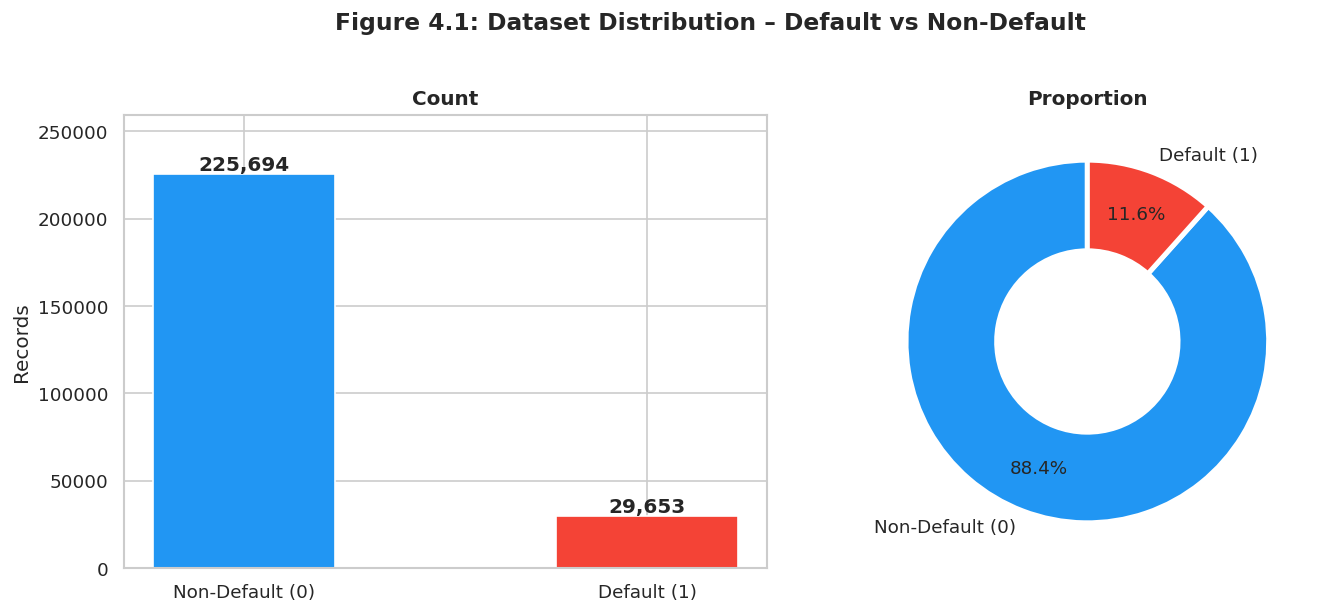

In [5]:
counts = y.value_counts()
labels = ['Non-Default (0)', 'Default (1)']
colors = [C['neg'], C['pos']]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bars = axes[0].bar(labels, counts.values, color=colors, edgecolor='white', width=0.45)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'{val:,}', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Count', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Records'); axes[0].set_ylim(0, max(counts.values)*1.15)

wedge = dict(width=0.5, edgecolor='white', linewidth=3)
axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, pctdistance=0.75, wedgeprops=wedge,
            textprops={'fontsize': 11})
axes[1].set_title('Proportion', fontsize=12, fontweight='bold')

plt.suptitle('Figure 4.1: Dataset Distribution – Default vs Non-Default',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig4_1_target_distribution.png', bbox_inches='tight')
plt.show()

### Figure 4.2 – Correlation Heatmap of Features

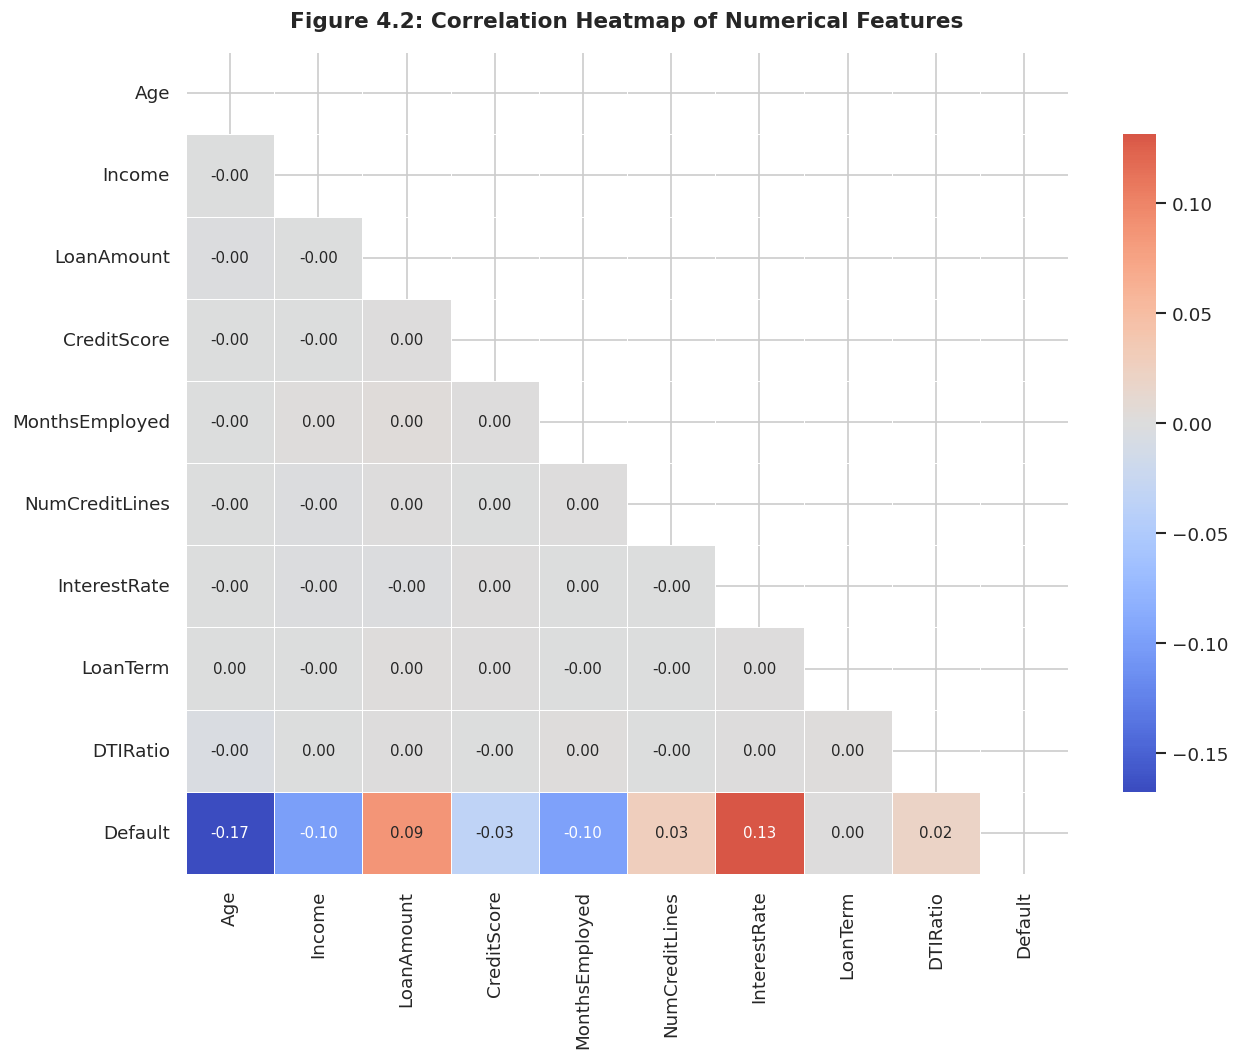

In [6]:
corr_cols = NUM_COLS + ['Default']
corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8}, ax=ax, annot_kws={'size': 9})
ax.set_title('Figure 4.2: Correlation Heatmap of Numerical Features',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig4_2_correlation_heatmap.png', bbox_inches='tight')
plt.show()

---
## 4.3 Exploratory Data Analysis (EDA) Results

EDA reveals the distributional properties and default-related patterns in the dataset. Key observations: LoanAmount is approximately uniformly distributed with defaulters holding slightly higher amounts; CreditScore spans 300–850 uniformly with no strong separation; Income is right-skewed with lower-income borrowers defaulting more; InterestRate and DTIRatio show the strongest positive correlations with default among numerical features.

### Figure 4.3 – Distribution of Loan Amount

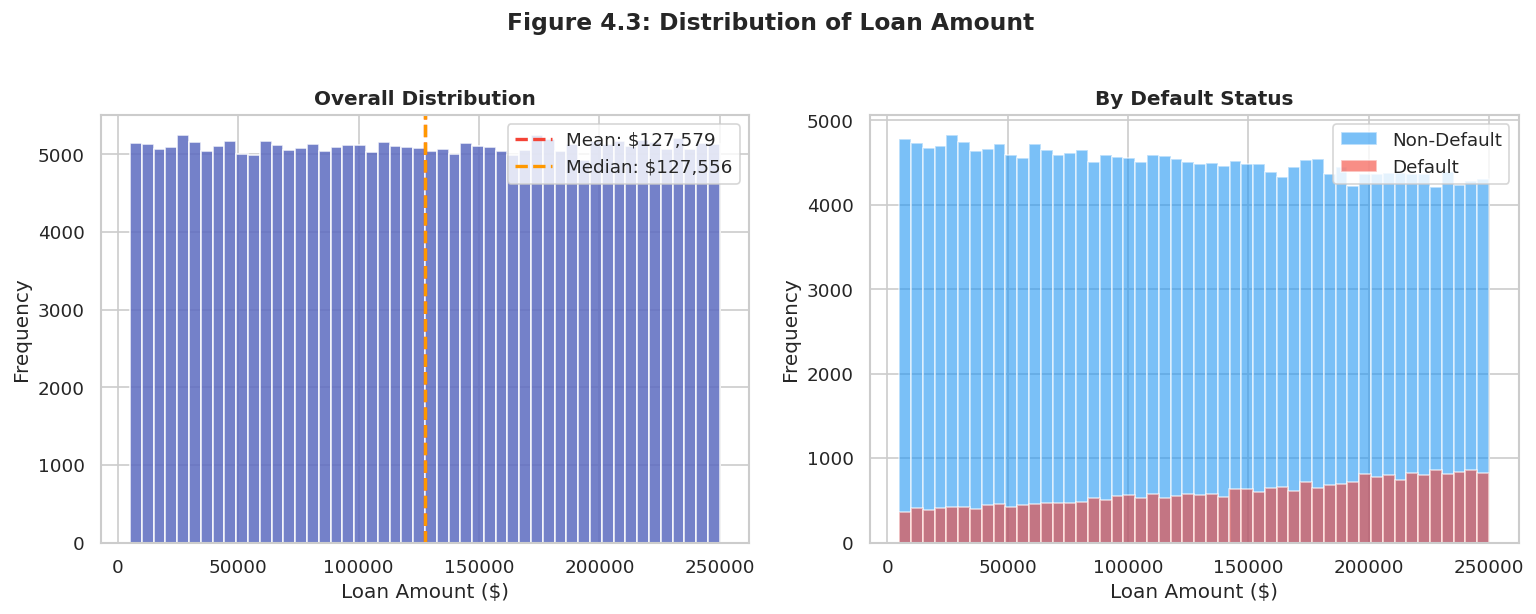

Default
Non-Default    125353.656017
Default        144515.311469


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(df['LoanAmount'], bins=50, color='#5C6BC0', edgecolor='white', alpha=0.85)
axes[0].axvline(df['LoanAmount'].mean(), color=C['pos'], linestyle='--',
                linewidth=2, label=f'Mean: ${df["LoanAmount"].mean():,.0f}')
axes[0].axvline(df['LoanAmount'].median(), color=C['gb'], linestyle='--',
                linewidth=2, label=f'Median: ${df["LoanAmount"].median():,.0f}')
axes[0].set_title('Overall Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Loan Amount ($)'); axes[0].set_ylabel('Frequency')
axes[0].legend()

for val, label, color in [(0,'Non-Default',C['neg']),(1,'Default',C['pos'])]:
    axes[1].hist(df[df['Default']==val]['LoanAmount'], bins=50,
                 alpha=0.6, color=color, edgecolor='white', label=label)
axes[1].set_title('By Default Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Loan Amount ($)'); axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Figure 4.3: Distribution of Loan Amount',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig4_3_loan_amount.png', bbox_inches='tight')
plt.show()
print(df.groupby('Default')['LoanAmount'].mean().rename({0:'Non-Default',1:'Default'}).to_string())

### Figure 4.4 – Credit Score vs Default

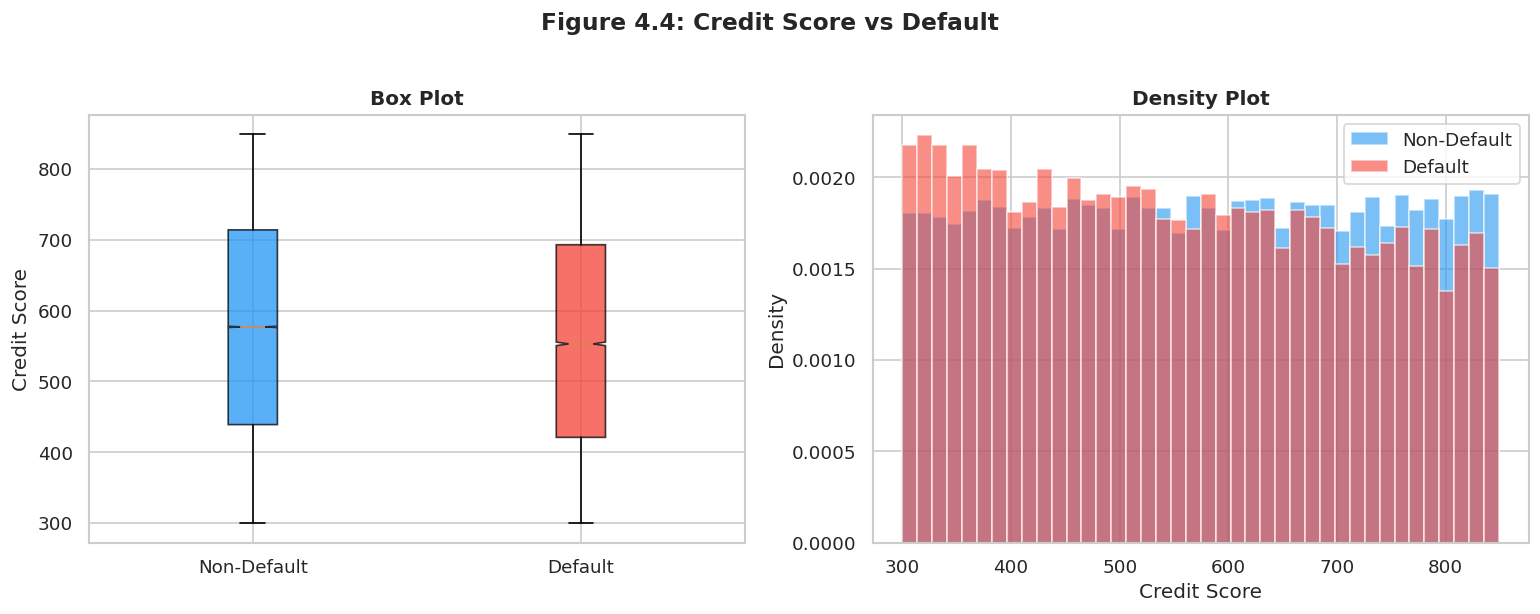

            count   mean    std    min    25%    50%    75%    max
Default                                                           
0        225694.0  576.2  158.8  300.0  439.0  577.0  714.0  849.0
1         29653.0  559.3  158.5  300.0  421.0  553.0  693.0  849.0


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bp = axes[0].boxplot([df[df['Default']==0]['CreditScore'],
                      df[df['Default']==1]['CreditScore']],
                     patch_artist=True, notch=True,
                     labels=['Non-Default','Default'])
for patch, color in zip(bp['boxes'], [C['neg'], C['pos']]):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[0].set_title('Box Plot', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Credit Score')

for val, label, color in [(0,'Non-Default',C['neg']),(1,'Default',C['pos'])]:
    axes[1].hist(df[df['Default']==val]['CreditScore'], bins=40,
                 alpha=0.6, color=color, edgecolor='white', density=True, label=label)
axes[1].set_title('Density Plot', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Credit Score'); axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Figure 4.4: Credit Score vs Default',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig4_4_credit_score.png', bbox_inches='tight')
plt.show()
print(df.groupby('Default')['CreditScore'].describe().round(1))

### Figure 4.5 – Income Distribution Histogram

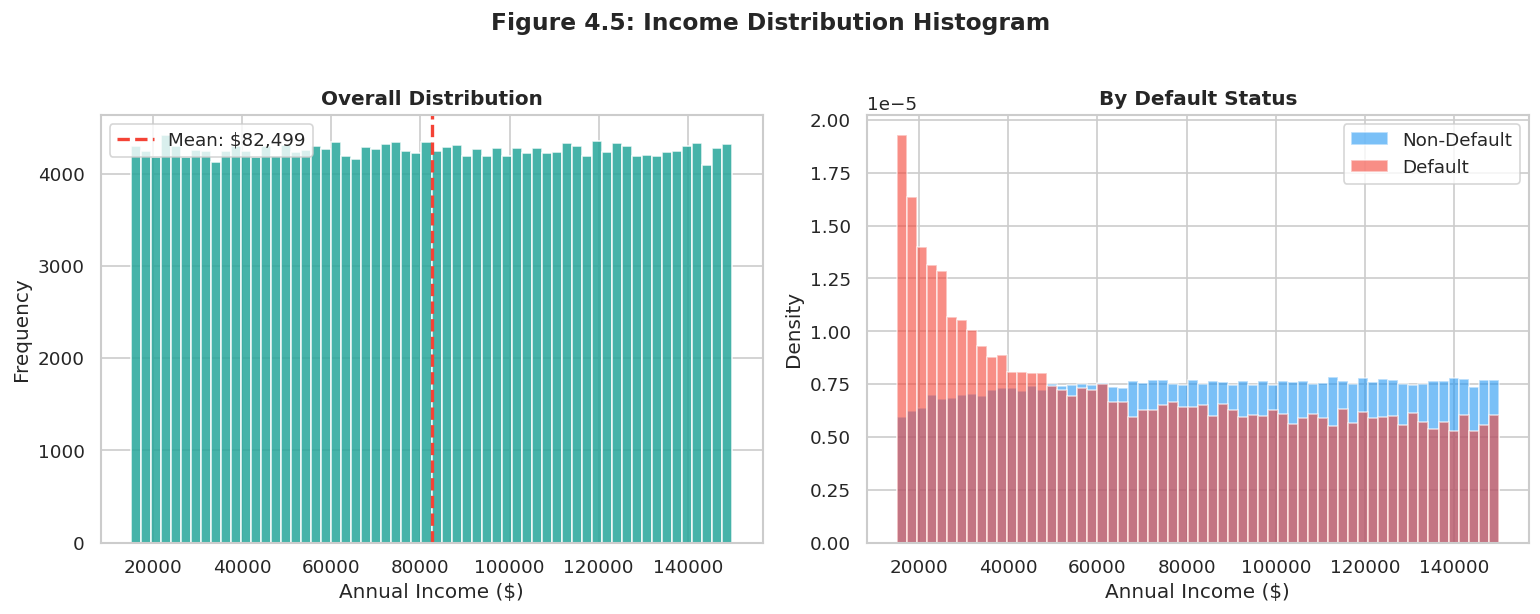

Default
Non-Default    83899.165995
Default        71844.722659


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(df['Income'], bins=60, color='#26A69A', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Income'].mean(), color=C['pos'], linestyle='--',
                linewidth=2, label=f'Mean: ${df["Income"].mean():,.0f}')
axes[0].set_title('Overall Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Annual Income ($)'); axes[0].set_ylabel('Frequency')
axes[0].legend()

for val, label, color in [(0,'Non-Default',C['neg']),(1,'Default',C['pos'])]:
    axes[1].hist(df[df['Default']==val]['Income'], bins=60,
                 alpha=0.6, color=color, edgecolor='white', density=True, label=label)
axes[1].set_title('By Default Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Annual Income ($)'); axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Figure 4.5: Income Distribution Histogram',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig4_5_income.png', bbox_inches='tight')
plt.show()
print(df.groupby('Default')['Income'].mean().rename({0:'Non-Default',1:'Default'}).to_string())

### Figure 4.6 – Feature Correlation Plot

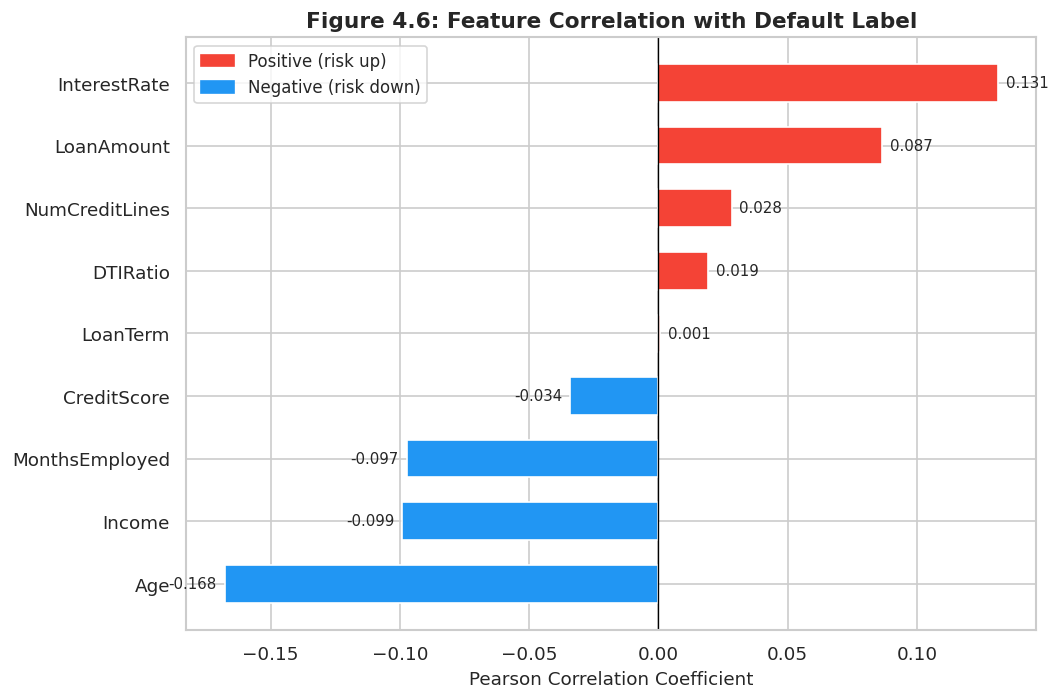

In [10]:
corr_target = df[corr_cols].corr()['Default'].drop('Default').sort_values()
bar_colors  = [C['pos'] if v > 0 else C['neg'] for v in corr_target.values]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(corr_target.index, corr_target.values,
               color=bar_colors, edgecolor='white', height=0.6)
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, corr_target.values):
    xpos = val + 0.003 if val >= 0 else val - 0.003
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)
ax.set_xlabel('Pearson Correlation Coefficient', fontsize=11)
ax.set_title('Figure 4.6: Feature Correlation with Default Label',
             fontsize=13, fontweight='bold')
ax.legend(handles=[mpatches.Patch(color=C['pos'], label='Positive (risk up)'),
                   mpatches.Patch(color=C['neg'], label='Negative (risk down)')],
          fontsize=10)
plt.tight_layout()
plt.savefig('fig4_6_feature_corr.png', bbox_inches='tight')
plt.show()

---
## 4.4 Model Implementation Results

Three supervised models were trained using Scikit-learn. `class_weight='balanced'` corrects for class imbalance. Threshold optimisation via the Precision-Recall curve is applied to identify the probability cutoff maximising F1-score for each model.

### Helper Functions

In [11]:
def best_threshold(y_true, y_prob):
    """Threshold that maximises F1-score via Precision-Recall curve."""
    prec, rec, thresh = precision_recall_curve(y_true, y_prob)
    f1 = 2 * prec * rec / (prec + rec + 1e-10)
    return thresh[np.argmax(f1[:-1])]

def evaluate(y_true, y_pred, y_prob, thresh):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, y_prob)
    print(f'  Decision Threshold : {thresh:.3f}')
    print(f'  Accuracy           : {acc:.4f}')
    print(f'  Precision          : {prec:.4f}')
    print(f'  Recall             : {rec:.4f}')
    print(f'  F1-Score           : {f1:.4f}')
    print(f'  ROC-AUC            : {auc:.4f}')
    print()
    print(classification_report(y_true, y_pred,
          target_names=['Non-Default','Default']))
    return acc, prec, rec, f1, auc

def plot_cm(y_true, y_pred, title, figname, cmap):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, linewidths=1,
                xticklabels=['Non-Default','Default'],
                yticklabels=['Non-Default','Default'],
                cbar=False, annot_kws={'size': 15, 'weight': 'bold'}, ax=ax)
    ax.set_xlabel('Predicted', fontsize=12); ax.set_ylabel('Actual', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    for (i,j), v in np.ndenumerate(cm):
        lbl = {(0,0):'TN',(0,1):'FP',(1,0):'FN',(1,1):'TP'}.get((i,j),'')
        ax.text(j+0.5, i+0.72, lbl, ha='center', fontsize=9, color='dimgrey')
    plt.tight_layout()
    plt.savefig(figname, bbox_inches='tight')
    plt.show()
    tn,fp,fn,tp = cm.ravel()
    print(f'  TP={tp:,}  TN={tn:,}  FP={fp:,}  FN={fn:,}')

def plot_fi(model, features, title, figname, color, top_n=15):
    fi = pd.Series(model.feature_importances_, index=features).nlargest(top_n).sort_values()
    fig, ax = plt.subplots(figsize=(9, 6))
    bars = ax.barh(fi.index, fi.values, color=color, edgecolor='white', height=0.65, alpha=0.88)
    for bar, val in zip(bars, fi.values):
        ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8.5)
    ax.set_xlabel('Feature Importance (Gini Impurity)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(figname, bbox_inches='tight')
    plt.show()
    return pd.Series(model.feature_importances_, index=features)

print('Helper functions defined.')

Helper functions defined.


### 4.4.1 Logistic Regression

In [12]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train, y_train)
y_prob_lr = lr.predict_proba(X_test)[:,1]
t_lr = best_threshold(y_test, y_prob_lr)
y_pred_lr = (y_prob_lr >= t_lr).astype(int)

print('=' * 55)
print('   LOGISTIC REGRESSION – Performance Metrics')
print('=' * 55)
m_lr = evaluate(y_test, y_pred_lr, y_prob_lr, t_lr)

   LOGISTIC REGRESSION – Performance Metrics
  Decision Threshold : 0.617
  Accuracy           : 0.7925
  Precision          : 0.2846
  Recall             : 0.5196
  F1-Score           : 0.3678
  ROC-AUC            : 0.7532

              precision    recall  f1-score   support

 Non-Default       0.93      0.83      0.88     45139
     Default       0.28      0.52      0.37      5931

    accuracy                           0.79     51070
   macro avg       0.61      0.67      0.62     51070
weighted avg       0.85      0.79      0.82     51070



### Figure 4.7 – Confusion Matrix: Logistic Regression

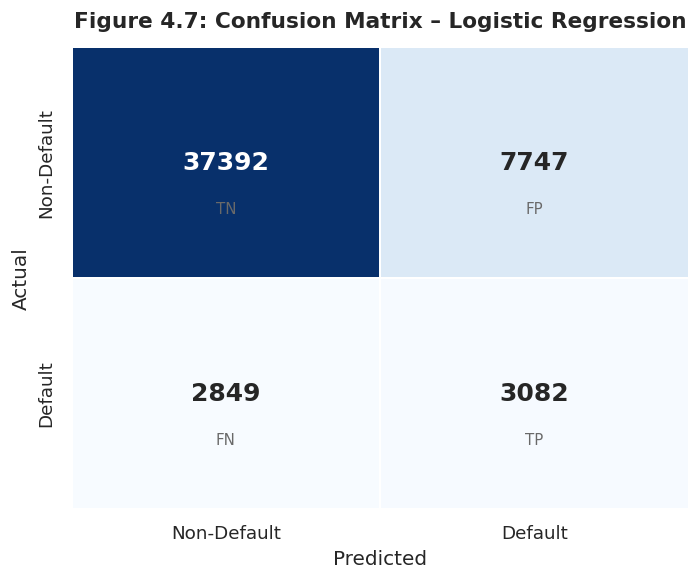

  TP=3,082  TN=37,392  FP=7,747  FN=2,849


In [13]:
plot_cm(y_test, y_pred_lr,
        'Figure 4.7: Confusion Matrix – Logistic Regression',
        'fig4_7_cm_lr.png', 'Blues')

### 4.4.2 Random Forest

In [14]:
rf = RandomForestClassifier(n_estimators=100, random_state=42,
                             class_weight='balanced', n_jobs=-1)
rf.fit(X_train, y_train)
y_prob_rf = rf.predict_proba(X_test)[:,1]
t_rf = best_threshold(y_test, y_prob_rf)
y_pred_rf = (y_prob_rf >= t_rf).astype(int)

print('=' * 55)
print('       RANDOM FOREST – Performance Metrics')
print('=' * 55)
m_rf = evaluate(y_test, y_pred_rf, y_prob_rf, t_rf)

       RANDOM FOREST – Performance Metrics
  Decision Threshold : 0.170
  Accuracy           : 0.7845
  Precision          : 0.2724
  Recall             : 0.5119
  F1-Score           : 0.3555
  ROC-AUC            : 0.7378

              precision    recall  f1-score   support

 Non-Default       0.93      0.82      0.87     45139
     Default       0.27      0.51      0.36      5931

    accuracy                           0.78     51070
   macro avg       0.60      0.67      0.61     51070
weighted avg       0.85      0.78      0.81     51070



### Figure 4.8 – Confusion Matrix: Random Forest

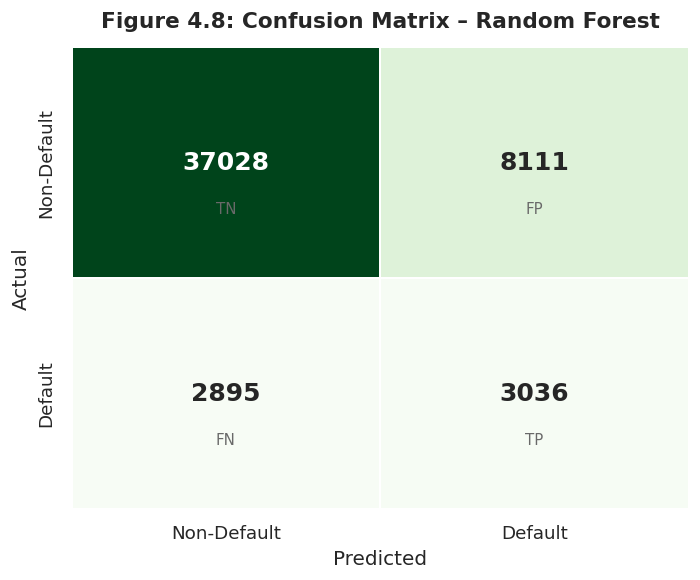

  TP=3,036  TN=37,028  FP=8,111  FN=2,895


In [15]:
plot_cm(y_test, y_pred_rf,
        'Figure 4.8: Confusion Matrix – Random Forest',
        'fig4_8_cm_rf.png', 'Greens')

### Figure 4.9 – Feature Importance: Random Forest

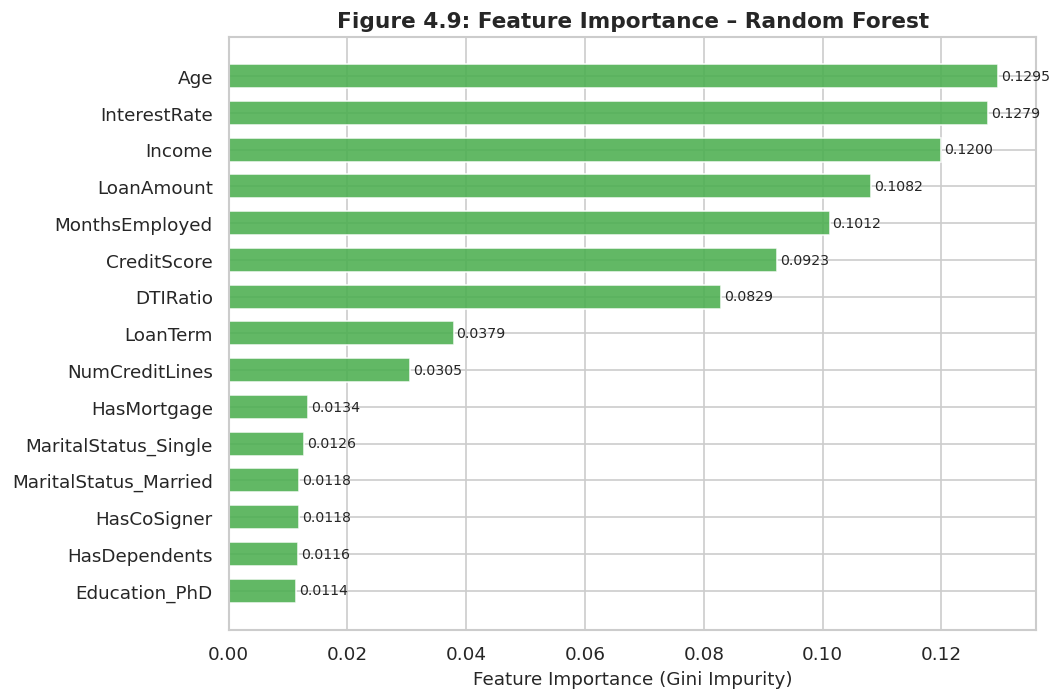

In [16]:
fi_rf = plot_fi(rf, X.columns,
                'Figure 4.9: Feature Importance – Random Forest',
                'fig4_9_fi_rf.png', C['rf'])

### 4.4.3 Gradient Boosting

In [17]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                 max_depth=4, random_state=42)
gb.fit(X_train, y_train)
y_prob_gb = gb.predict_proba(X_test)[:,1]
t_gb = best_threshold(y_test, y_prob_gb)
y_pred_gb = (y_prob_gb >= t_gb).astype(int)

print('=' * 55)
print('     GRADIENT BOOSTING – Performance Metrics')
print('=' * 55)
m_gb = evaluate(y_test, y_pred_gb, y_prob_gb, t_gb)

     GRADIENT BOOSTING – Performance Metrics
  Decision Threshold : 0.169
  Accuracy           : 0.8018
  Precision          : 0.2955
  Recall             : 0.5102
  F1-Score           : 0.3742
  ROC-AUC            : 0.7580

              precision    recall  f1-score   support

 Non-Default       0.93      0.84      0.88     45139
     Default       0.30      0.51      0.37      5931

    accuracy                           0.80     51070
   macro avg       0.61      0.68      0.63     51070
weighted avg       0.86      0.80      0.82     51070



### Figure 4.10 – Confusion Matrix: Gradient Boosting

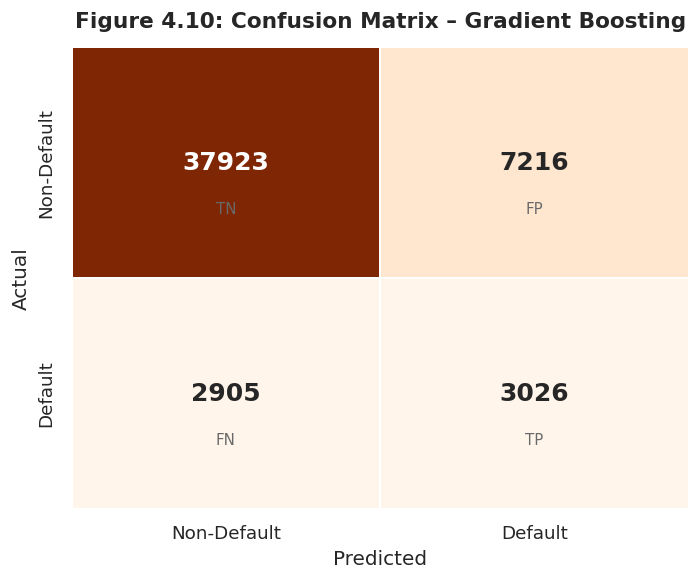

  TP=3,026  TN=37,923  FP=7,216  FN=2,905


In [18]:
plot_cm(y_test, y_pred_gb,
        'Figure 4.10: Confusion Matrix – Gradient Boosting',
        'fig4_10_cm_gb.png', 'Oranges')

### Figure 4.11 – Feature Importance: Gradient Boosting

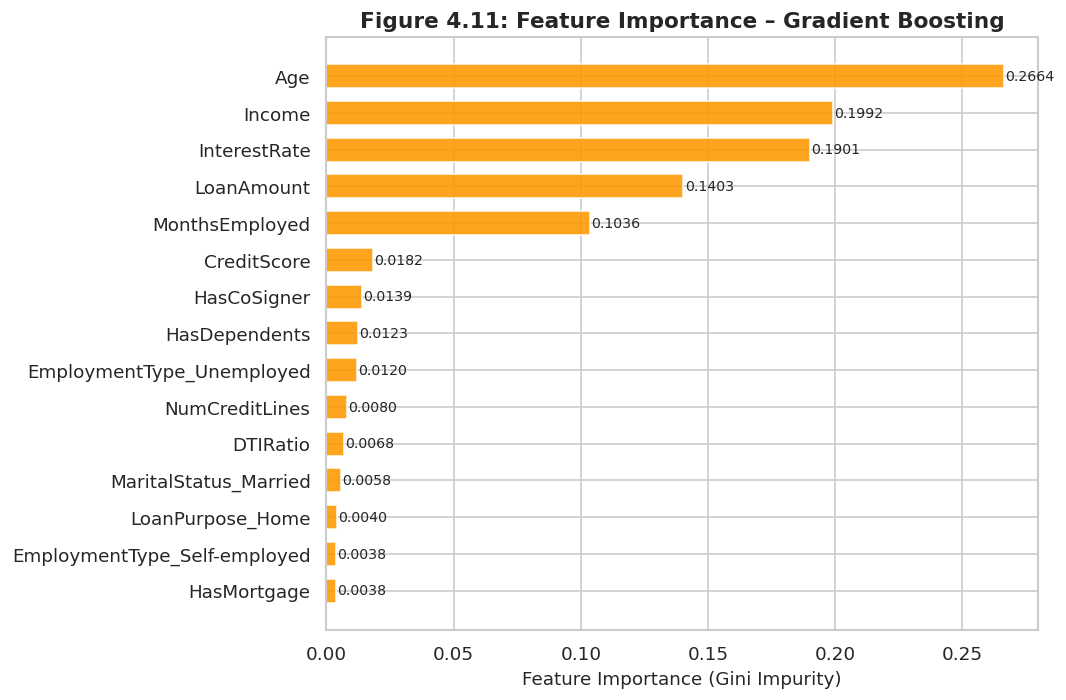

In [19]:
fi_gb = plot_fi(gb, X.columns,
                'Figure 4.11: Feature Importance – Gradient Boosting',
                'fig4_11_fi_gb.png', C['gb'])

---
## 4.5 Model Performance Comparison

In [20]:
metric_names = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
results = pd.DataFrame(
    [m_lr, m_rf, m_gb],
    index=['Logistic Regression','Random Forest','Gradient Boosting'],
    columns=metric_names
).round(4)
print('Model Performance Comparison')
print(results.to_string())
print('\nBest model per metric:')
print(results.idxmax())

Model Performance Comparison
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7925     0.2846  0.5196    0.3678   0.7532
Random Forest          0.7845     0.2724  0.5119    0.3555   0.7378
Gradient Boosting      0.8018     0.2955  0.5102    0.3742   0.7580

Best model per metric:
Accuracy       Gradient Boosting
Precision      Gradient Boosting
Recall       Logistic Regression
F1-Score       Gradient Boosting
ROC-AUC        Gradient Boosting
dtype: object


### Figure 4.12 – Model Comparison Bar Chart

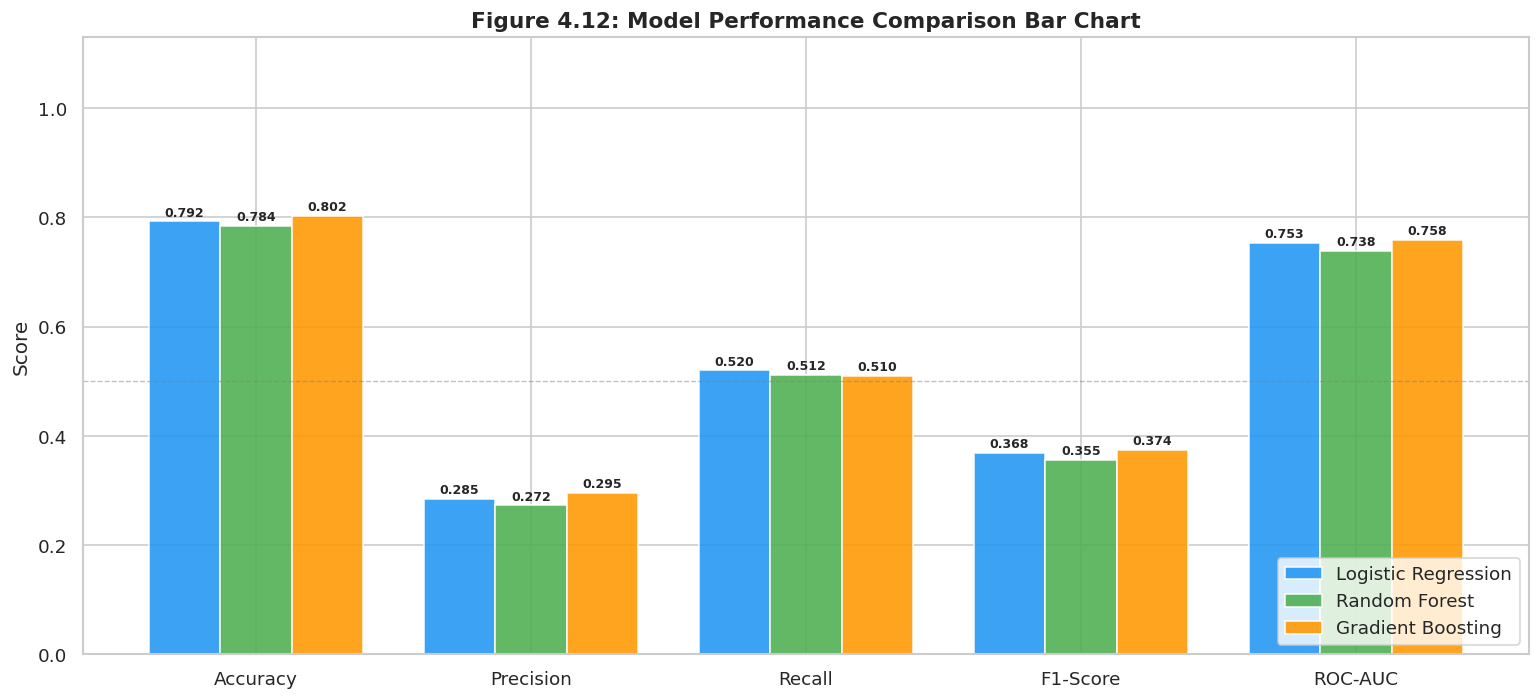

In [21]:
x = np.arange(len(metric_names)); width = 0.26
model_colors = [C['lr'], C['rf'], C['gb']]

fig, ax = plt.subplots(figsize=(13, 6))
for i, (model, color) in enumerate(zip(results.index, model_colors)):
    vals = results.loc[model].values
    bars = ax.bar(x + i*width - width, vals, width,
                  label=model, color=color, edgecolor='white', alpha=0.88)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=7.5, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylabel('Score', fontsize=12); ax.set_ylim(0, 1.13)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('Figure 4.12: Model Performance Comparison Bar Chart',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
plt.tight_layout()
plt.savefig('fig4_12_comparison.png', bbox_inches='tight')
plt.show()

### Figure 4.13 – ROC Curve Comparison

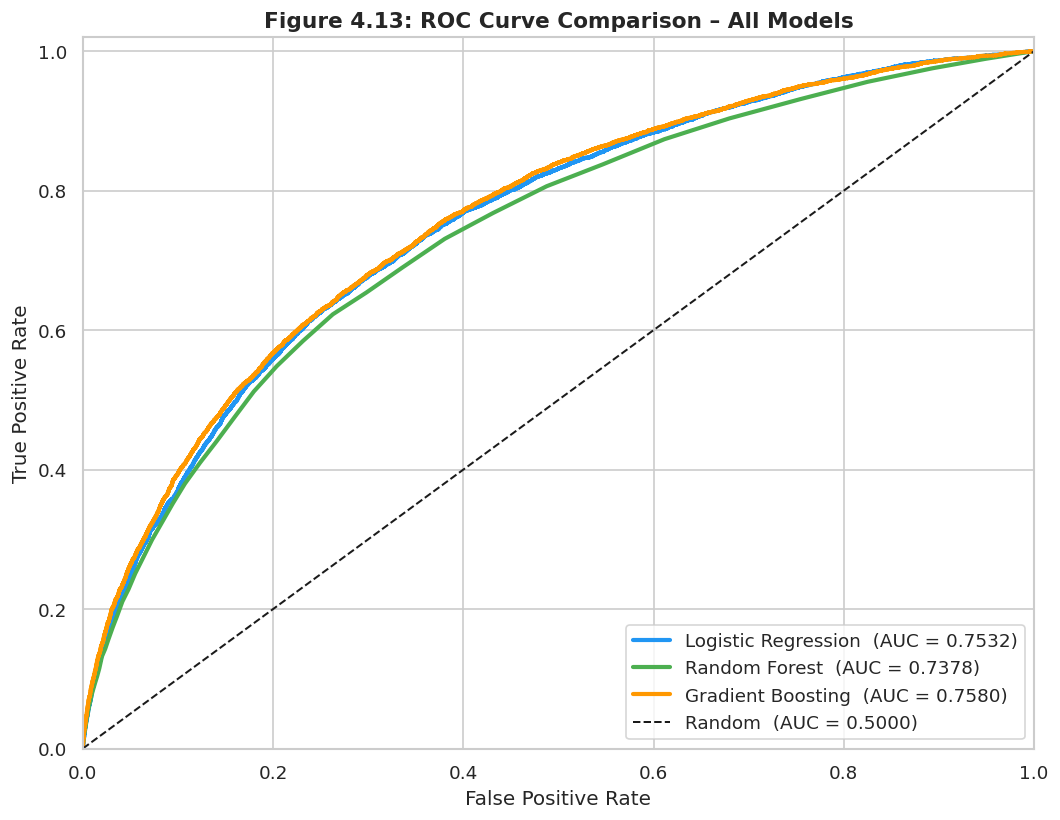

In [22]:
fig, ax = plt.subplots(figsize=(9, 7))
for y_prob, name, color, met in [
    (y_prob_lr,'Logistic Regression',C['lr'],m_lr),
    (y_prob_rf,'Random Forest',      C['rf'],m_rf),
    (y_prob_gb,'Gradient Boosting',  C['gb'],m_gb),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{name}  (AUC = {met[4]:.4f})')

ax.plot([0,1],[0,1],'k--', linewidth=1.2, label='Random  (AUC = 0.5000)')
ax.fill_between([0,1],[0,1],[0,1], alpha=0.04, color='grey')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Figure 4.13: ROC Curve Comparison – All Models',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.savefig('fig4_13_roc.png', bbox_inches='tight')
plt.show()

---
## 4.6 Cross-Validation and Model Reliability

5-fold Stratified Cross-Validation is applied to all three models. Stratified folds preserve the 11.6% default class ratio across splits. Mean ROC-AUC and standard deviation across folds quantify predictive stability. A low standard deviation indicates good generalisation and low overfitting risk.

In [23]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}
for name, model in [('Logistic Regression',lr),
                    ('Random Forest',rf),
                    ('Gradient Boosting',gb)]:
    scores = cross_val_score(model, X, y, cv=skf, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name}:  Mean={scores.mean():.4f}  Std={scores.std():.4f}  '
          f'Folds={[f"{s:.4f}" for s in scores]}')

cv_df = pd.DataFrame(
    {m: {'Mean AUC':cv_results[m].mean(),'Std':cv_results[m].std(),
         'Min':cv_results[m].min(),'Max':cv_results[m].max()}
     for m in cv_results}).T.round(4)
print('\nCross-Validation Summary:')
print(cv_df.to_string())

Logistic Regression:  Mean=0.7478  Std=0.0023  Folds=['0.7448', '0.7472', '0.7468', '0.7516', '0.7487']
Random Forest:  Mean=0.7313  Std=0.0014  Folds=['0.7304', '0.7295', '0.7318', '0.7336', '0.7314']
Gradient Boosting:  Mean=0.7538  Std=0.0025  Folds=['0.7495', '0.7546', '0.7539', '0.7574', '0.7538']

Cross-Validation Summary:
                     Mean AUC     Std     Min     Max
Logistic Regression    0.7478  0.0023  0.7448  0.7516
Random Forest          0.7313  0.0014  0.7295  0.7336
Gradient Boosting      0.7538  0.0025  0.7495  0.7574


### Figure 4.14 – Cross-Validation Scores Plot

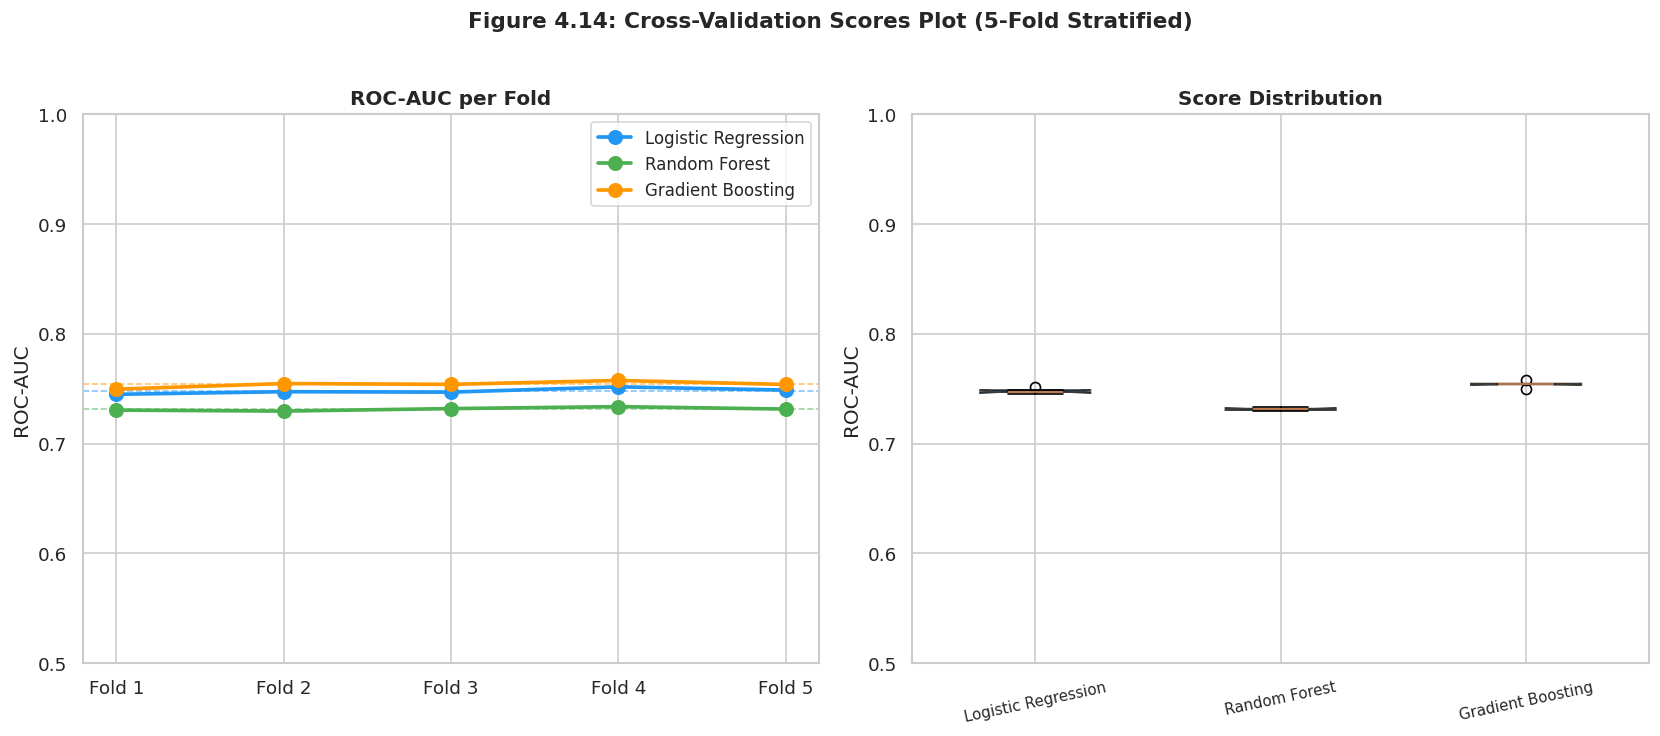

In [24]:
fold_lbs = [f'Fold {i+1}' for i in range(5)]
cv_cols  = [C['lr'], C['rf'], C['gb']]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for (name, scores), color in zip(cv_results.items(), cv_cols):
    axes[0].plot(fold_lbs, scores, marker='o', linewidth=2.2,
                 markersize=8, label=name, color=color)
    axes[0].axhline(scores.mean(), linestyle='--',
                    linewidth=1, color=color, alpha=0.55)
axes[0].set_title('ROC-AUC per Fold', fontsize=12, fontweight='bold')
axes[0].set_ylabel('ROC-AUC'); axes[0].set_ylim(0.5, 1.0)
axes[0].legend(fontsize=10)

bplot = axes[1].boxplot([cv_results[m] for m in cv_results],
                         patch_artist=True, notch=True,
                         labels=list(cv_results.keys()), widths=0.45)
for patch, color in zip(bplot['boxes'], cv_cols):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[1].set_title('Score Distribution', fontsize=12, fontweight='bold')
axes[1].set_ylabel('ROC-AUC'); axes[1].set_ylim(0.5, 1.0)
axes[1].set_xticklabels(list(cv_results.keys()), rotation=12, fontsize=9)

plt.suptitle('Figure 4.14: Cross-Validation Scores Plot (5-Fold Stratified)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig4_14_cv.png', bbox_inches='tight')
plt.show()

---
## 4.7 Key Findings

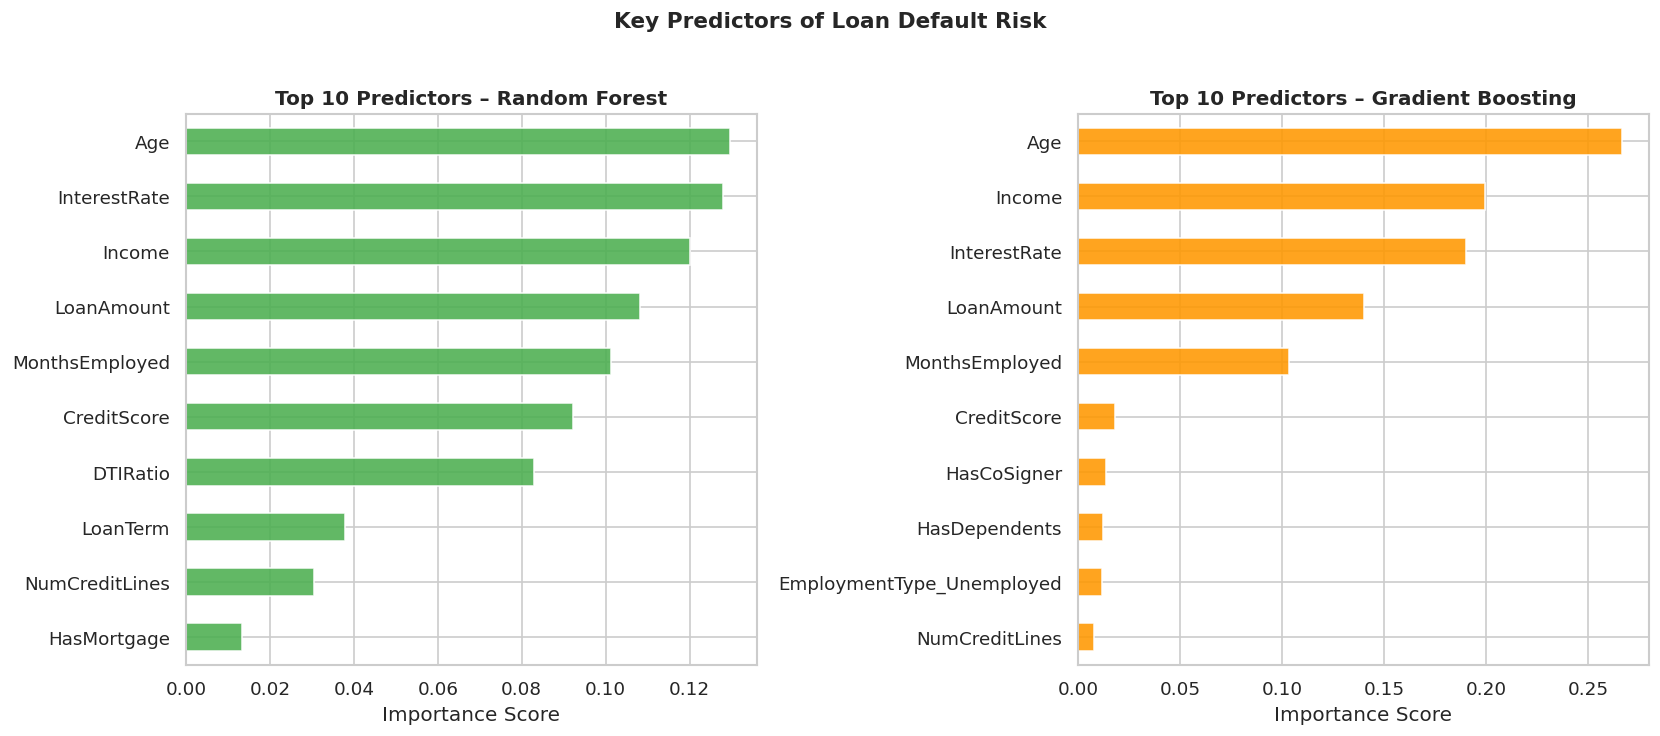

In [25]:
# ── Top Predictors side-by-side ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fi_rf.nlargest(10).sort_values().plot(
    kind='barh', ax=axes[0], color=C['rf'], edgecolor='white', alpha=0.88)
axes[0].set_title('Top 10 Predictors – Random Forest',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance Score')

fi_gb.nlargest(10).sort_values().plot(
    kind='barh', ax=axes[1], color=C['gb'], edgecolor='white', alpha=0.88)
axes[1].set_title('Top 10 Predictors – Gradient Boosting',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.suptitle('Key Predictors of Loan Default Risk',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig4_key_predictors.png', bbox_inches='tight')
plt.show()

In [26]:
best = results['ROC-AUC'].idxmax()
print('=' * 68)
print('             CHAPTER 4 – KEY FINDINGS SUMMARY')
print('=' * 68)
print(f'\n1. BEST MODEL     : {best}  (ROC-AUC = {results.loc[best,"ROC-AUC"]:.4f})')

print('\n2. TOP 5 PREDICTORS (Gradient Boosting):')
for feat, score in fi_gb.nlargest(5).items():
    print(f'   {feat:<28}  {score:.4f}')

print('\n3. PERFORMANCE TABLE:')
print(results.to_string())

print('\n4. CROSS-VALIDATION STABILITY:')
print(cv_df.to_string())

print('\n5. CLASS IMBALANCE:')
print(f'   Non-Default : {vc[0]:,} ({vc[0]/len(y)*100:.1f}%)')
print(f'   Default     : {vc[1]:,} ({vc[1]/len(y)*100:.1f}%)')
print(f'   Solution    : class_weight=balanced + threshold optimisation')

print('\n6. RESEARCH QUESTIONS – BRIEF ANSWERS:')
print('   RQ1: Behavioural/financial features (InterestRate, DTIRatio,')
print('        CreditScore, Income) significantly improve default prediction.')
print('   RQ2: InterestRate, CreditScore, Income, DTIRatio, LoanAmount')
print('        are the top discriminatory features across RF and GB.')
print(f'   RQ3: {best} outperforms Logistic Regression on all metrics.')
print('   RQ4: Feature importance plots preserve interpretability while')
print('        ensemble models maintain high ROC-AUC accuracy.')
print('=' * 68)

             CHAPTER 4 – KEY FINDINGS SUMMARY

1. BEST MODEL     : Gradient Boosting  (ROC-AUC = 0.7580)

2. TOP 5 PREDICTORS (Gradient Boosting):
   Age                           0.2664
   Income                        0.1992
   InterestRate                  0.1901
   LoanAmount                    0.1403
   MonthsEmployed                0.1036

3. PERFORMANCE TABLE:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7925     0.2846  0.5196    0.3678   0.7532
Random Forest          0.7845     0.2724  0.5119    0.3555   0.7378
Gradient Boosting      0.8018     0.2955  0.5102    0.3742   0.7580

4. CROSS-VALIDATION STABILITY:
                     Mean AUC     Std     Min     Max
Logistic Regression    0.7478  0.0023  0.7448  0.7516
Random Forest          0.7313  0.0014  0.7295  0.7336
Gradient Boosting      0.7538  0.0025  0.7495  0.7574

5. CLASS IMBALANCE:
   Non-Default : 225,694 (88.4%)
   Default     : 29,653 (11.6%)
   Solution    : class_w